In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os

# Path to the dataset (adjust if different)
source_dir = "/content/drive/MyDrive/project/basepaper/EuroSAT_preprocessed1"

# Check if directory exists
if os.path.exists(source_dir):
    print("✅ Dataset found at:", source_dir)
else:
    print("❌ Dataset not found. Please check the path.")

✅ Dataset found at: /content/drive/MyDrive/project/basepaper/EuroSAT_preprocessed1


In [ ]:
import os
import shutil
from tqdm import tqdm

source_dir = "/content/drive/MyDrive/project/basepaper/EuroSAT_preprocessed1"
target_dir = "/content/EuroSAT_50"

os.makedirs(target_dir, exist_ok=True)

classes = [cls for cls in os.listdir(source_dir) if os.path.isdir(os.path.join(source_dir, cls))]
limit = 50

for cls in tqdm(classes, desc="Copying 50 images/class"):
    src_cls_path = os.path.join(source_dir, cls)
    dst_cls_path = os.path.join(target_dir, cls)
    os.makedirs(dst_cls_path, exist_ok=True)

    images = sorted([img for img in os.listdir(src_cls_path) if img.lower().endswith(('.jpg', '.jpeg', '.png'))])[:limit]
    for img in images:
        shutil.copy(os.path.join(src_cls_path, img), os.path.join(dst_cls_path, img))

print("✅ Created dataset with 50 images per class at:", target_dir)


Copying 50 images/class: 100%|██████████| 10/10 [11:02<00:00, 66.23s/it]

✅ Created dataset with 50 images per class at: /content/EuroSAT_50


In [ ]:
import os
import shutil
from sklearn.model_selection import train_test_split
from tqdm import tqdm

source_dir = "/content/EuroSAT_50"
target_dir = "/content/EuroSAT_50_split"
train_dir = os.path.join(target_dir, "train")
val_dir = os.path.join(target_dir, "val")

os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)

for cls in tqdm(os.listdir(source_dir), desc="Splitting dataset"):
    src_cls_path = os.path.join(source_dir, cls)
    if not os.path.isdir(src_cls_path):
        continue

    images = sorted([f for f in os.listdir(src_cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    train_imgs, val_imgs = train_test_split(images, test_size=0.2, random_state=42)

    os.makedirs(os.path.join(train_dir, cls), exist_ok=True)
    os.makedirs(os.path.join(val_dir, cls), exist_ok=True)

    for img in train_imgs:
        shutil.copy(os.path.join(src_cls_path, img), os.path.join(train_dir, cls, img))

    for img in val_imgs:
        shutil.copy(os.path.join(src_cls_path, img), os.path.join(val_dir, cls, img))

print("✅ Dataset split into train/val at:", target_dir)


Splitting dataset: 100%|██████████| 10/10 [00:00<00:00, 20.44it/s]

✅ Dataset split into train/val at: /content/EuroSAT_50_split


In [ ]:
import os

train_dir = "/content/EuroSAT_50_split/train"
val_dir = "/content/EuroSAT_50_split/val"

print("Train classes:", os.listdir(train_dir))
print("Val classes:", os.listdir(val_dir))


Train classes: ['PermanentCrop', 'Pasture', 'Forest', 'River', 'AnnualCrop', 'SeaLake', 'Highway', 'HerbaceousVegetation', 'Residential', 'Industrial']
Val classes: ['PermanentCrop', 'Pasture', 'Forest', 'River', 'AnnualCrop', 'SeaLake', 'Highway', 'HerbaceousVegetation', 'Residential', 'Industrial']


In [ ]:
data_dir = "/content/EuroSAT_50_split"
train_dir = os.path.join(data_dir, "train")
val_dir = os.path.join(data_dir, "val")


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 26.9MB/s]


🔁 Training started...



Epoch 1/10: 100%|██████████| 25/25 [01:54<00:00,  4.60s/it]


Epoch [1/10] - Loss: 2.0772


Epoch 2/10: 100%|██████████| 25/25 [01:38<00:00,  3.95s/it]


...

Epoch [8/10] - Loss: 0.2253


Epoch 9/10: 100%|██████████| 25/25 [01:40<00:00,  4.04s/it]


Epoch [9/10] - Loss: 0.2029


Epoch 10/10: 100%|██████████| 25/25 [01:41<00:00,  4.06s/it]


Epoch [10/10] - Loss: 0.1836

🧪 Evaluating on validation set...

📊 Classification Report:
                      precision    recall  f1-score   support

          AnnualCrop       0.73      0.80      0.76        10
              Forest       0.91      1.00      0.95        10
HerbaceousVegetation       0.82      0.90      0.86        10
             Highway       0.89      0.80      0.84        10
          Industrial       1.00      1.00      1.00        10
             Pasture       1.00      0.80      0.89        10
       PermanentCrop       0.80      0.80      0.80        10
         Residential       1.00      1.00      1.00        10
               River       0.91      1.00      0.95        10
             SeaLake       1.00      0.90      0.95        10

            accuracy                           0.90       100
           macro avg       0.91      0.90      0.90       100
        weighted avg       0.91      0.90      0.90       100



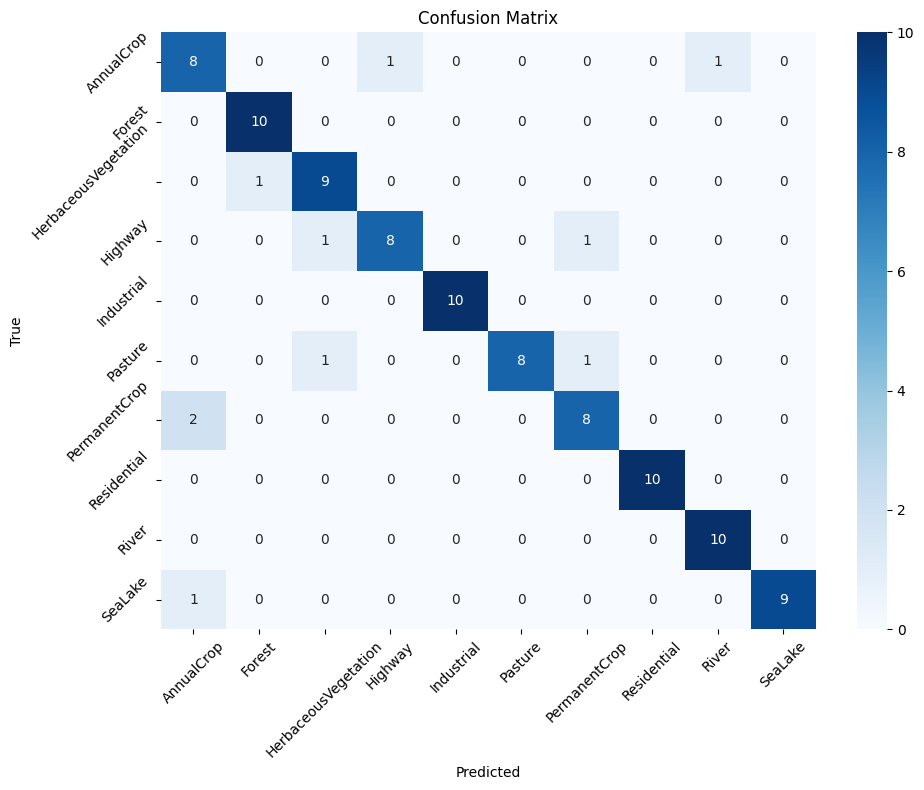

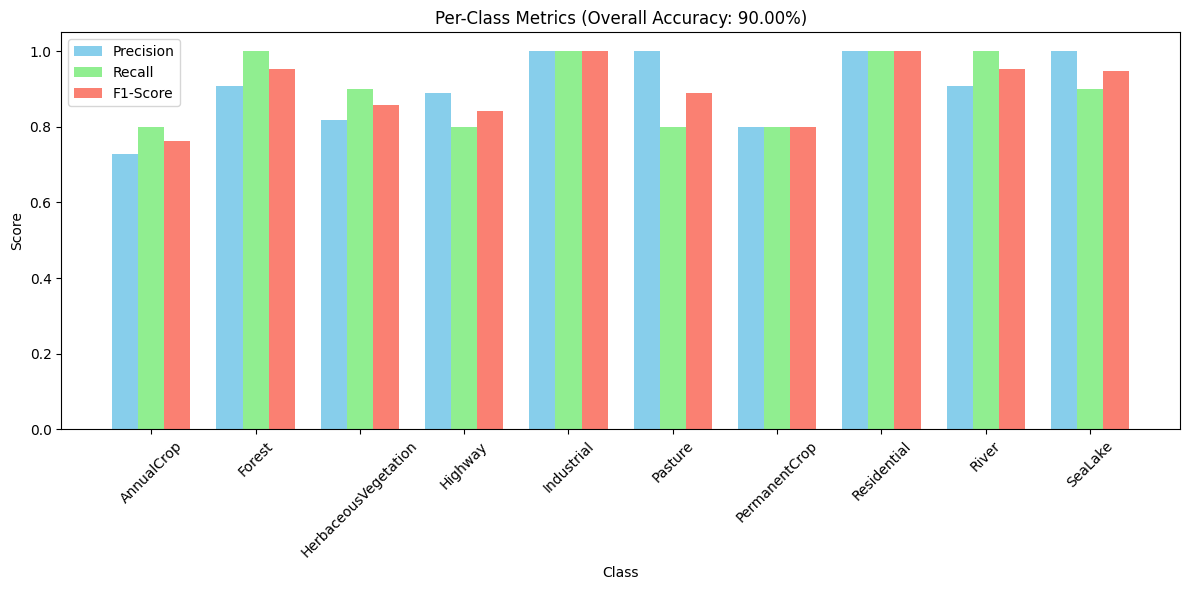

In [ ]:
import os
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from tqdm import tqdm

# ===== Configuration =====
data_dir = "/content/EuroSAT_50_split"
train_dir = os.path.join(data_dir, "train")
val_dir = os.path.join(data_dir, "val")
batch_size = 16
num_epochs = 10
num_classes = len(os.listdir(train_dir))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===== Transforms =====
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# ===== Dataset and Dataloaders =====
train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset = datasets.ImageFolder(val_dir, transform=val_transform)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False)
class_names = train_dataset.classes

# ===== Load EfficientNet-B0 =====
model = models.efficientnet_b0(pretrained=True)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
model = model.to(device)

# ===== Loss and Optimizer =====
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# ===== Training Loop =====
print("🔁 Training started...\n")
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {running_loss/len(train_loader):.4f}")

# ===== Evaluation =====
print("\n🧪 Evaluating on validation set...")
model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        y_true.append(labels.item())
        y_pred.append(preds.cpu().item())

# ===== Classification Report =====
print("\n📊 Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# ===== Confusion Matrix =====
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()

# ===== Precision, Recall, F1 Bar Chart =====
precision, recall, f1_score, _ = precision_recall_fscore_support(y_true, y_pred)
accuracy = accuracy_score(y_true, y_pred)

x = np.arange(len(class_names))
width = 0.25

plt.figure(figsize=(12, 6))
plt.bar(x - width, precision, width, label='Precision', color='skyblue')
plt.bar(x, recall, width, label='Recall', color='lightgreen')
plt.bar(x + width, f1_score, width, label='F1-Score', color='salmon')
plt.xticks(x, class_names, rotation=45)
plt.xlabel("Class")
plt.ylabel("Score")
plt.title(f"Per-Class Metrics (Overall Accuracy: {accuracy:.2%})")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_true, y_pred)
print(f"✅ Accuracy: {accuracy * 100:.2f}%")


✅ Accuracy: 90.00%


In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import matplotlib.pyplot as plt


In [ ]:
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense


In [ ]:
import os
import shutil
from tqdm import tqdm
from PIL import Image

source_dir = "/content/drive/MyDrive/project/basepaper/EuroSAT_preprocessed1"
target_dir = "/content/EuroSAT_50_300x300"

os.makedirs(target_dir, exist_ok=True)

classes = [cls for cls in os.listdir(source_dir) if os.path.isdir(os.path.join(source_dir, cls))]
limit = 50

for cls in tqdm(classes, desc="Copying and resizing 50 images/class"):
    src_cls_path = os.path.join(source_dir, cls)
    dst_cls_path = os.path.join(target_dir, cls)
    os.makedirs(dst_cls_path, exist_ok=True)

    images = sorted([img for img in os.listdir(src_cls_path) if img.lower().endswith(('.jpg', '.jpeg', '.png'))])[:limit]

    for img_name in images:
        img_path = os.path.join(src_cls_path, img_name)
        img = Image.open(img_path).convert("RGB")
        img = img.resize((300, 300))  # Resize to 300x300

        save_path = os.path.join(dst_cls_path, img_name)
        img.save(save_path)

print("✅ Created dataset with 50 resized (300x300) images per class at:", target_dir)


Copying and resizing 50 images/class: 100%|██████████| 10/10 [06:54<00:00, 41.43s/it]

✅ Created dataset with 50 resized (300x300) images per class at: /content/EuroSAT_50_300x300


In [ ]:
import os
import random
import shutil
from tqdm import tqdm

# Set paths
dataset_dir = "/content/EuroSAT_50_300x300"   # Already resized dataset
output_dir = "/content/EuroSAT_split"         # Where split folders will go

# Set split ratios
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15  # Implicitly from remainder
seed = 42
random.seed(seed)

# Prepare folders
splits = ['train', 'val', 'test']
classes = [cls for cls in os.listdir(dataset_dir) if os.path.isdir(os.path.join(dataset_dir, cls))]

# Create output folders
for split in splits:
    for cls in classes:
        os.makedirs(os.path.join(output_dir, split, cls), exist_ok=True)

# Copy and split
for cls in tqdm(classes, desc="Splitting into train/val/test"):
    cls_dir = os.path.join(dataset_dir, cls)
    images = [img for img in os.listdir(cls_dir) if img.lower().endswith(('.jpg', '.jpeg', '.png'))]
    random.shuffle(images)

    n_total = len(images)
    n_train = int(n_total * train_ratio)
    n_val = int(n_total * val_ratio)

    split_data = {
        'train': images[:n_train],
        'val': images[n_train:n_train + n_val],
        'test': images[n_train + n_val:]
    }

    for split, imgs in split_data.items():
        for img in imgs:
            src = os.path.join(cls_dir, img)
            dst = os.path.join(output_dir, split, cls, img)
            shutil.copy(src, dst)

print(f"✅ Train/val/test split completed at: {output_dir}")


Splitting into train/val/test: 100%|██████████| 10/10 [00:00<00:00, 42.44it/s]

✅ Train/val/test split completed at: /content/EuroSAT_split


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Constants
IMG_SIZE = (300, 300)
BATCH_SIZE = 32
NUM_EPOCHS = 10
DATA_ROOT = "/content/EuroSAT_split"  # from previous step

# Load datasets
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATA_ROOT + "/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"  # one-hot encoded
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATA_ROOT + "/val",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

# Class info
class_names = train_ds.class_names
num_classes = len(class_names)

# Performance optimization
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

# Data augmentation and preprocessing
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.1),
], name="data_augmentation")

preprocess = layers.Lambda(preprocess_input, name="effnet_preprocess")

# EfficientNet-B3 model
base_model = EfficientNetB3(
    include_top=False,
    weights="imagenet",
    input_shape=IMG_SIZE + (3,),
    pooling="avg"
)
base_model.trainable = False  # freeze base model

# Model architecture
inputs = layers.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = preprocess(x)
x = base_model(x, training=False)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = models.Model(inputs, outputs)

# Compile model
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Callbacks
early_stop = EarlyStopping(monitor="val_accuracy", patience=4, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=2, verbose=1)

# Train
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=NUM_EPOCHS,
    callbacks=[early_stop, reduce_lr]
)


Found 350 files belonging to 10 classes.
Found 70 files belonging to 10 classes.
Epoch 1/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 169s 13s/step - accuracy: 0.2453 - loss: 2.1971 - val_accuracy: 0.6000 - val_loss: 1.6866 - learning_rate: 0.0010
Epoch 2/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 122s 11s/step - accuracy: 0.5777 - loss: 1.5882 - val_accuracy: 0.7429 - val_loss: 1.3075 - learning_rate: 0.0010
Epoch 3/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 123s 11s/step - accuracy: 0.6620 - loss: 1.3113 - val_accuracy: 0.8286 - val_loss: 1.0521 - learning_rate: 0.0010
Epoch 4/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 122s 11s/step - accuracy: 0.7553 - loss: 1.0586 - val_accuracy: 0.8429 - val_loss: 0.8952 - learning_rate: 0.0010
Epoch 5/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 140s 11s/step - accuracy: 0.7749 - loss: 0.9258 - val_accuracy: 0.8286 - val_loss: 0.7778 - learning_rate: 0.0010
Epoch 6/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 121s 11s/step - accuracy: 0.8298 - loss: 0.7949 - val_accuracy: 0.8571 - val_loss: 0.7031 - learning_rate: 0.0010
Epoch 7